# SHAP Analysis MLP

Feature importances for 18 experiments (6 non-baseline feature sets × 3 splits).

SHAP values computed via PermutationExplainer (model-agnostic, works with sklearn Pipelines).  
Results cached as .npz

In [1]:
import os, sys, json, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore")
shap.initjs()

ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from src.data_utils import load_experiment

MODELS_DIR  = ROOT / "models" / "mlp"
RESULTS_DIR = ROOT / "results" / "mlp" / "shap"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Skip baseline
FEATURE_SETS = ["geo_decorr", "geo_all", "rac_decorr", "rac_all",
                "combined_decorr", "combined_all"]
SPLITS = ["random", "metal", "topology"]

cfg = json.loads((ROOT / "data/merged/feature_selection.json").read_text())
FEATURE_SET_COLS = cfg["feature_sets"]

GEO_COLOUR = "#4C72B0"
RAC_COLOUR  = "#DD8452"

print(f"Models dir : {MODELS_DIR}")
print(f"Results dir: {RESULTS_DIR}")

/Users/hannah/anaconda3/envs/mof_mlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Models dir : /Users/hannah/Desktop/ethz/Semester6/dc-mof-project/models/mlp
Results dir: /Users/hannah/Desktop/ethz/Semester6/dc-mof-project/results/mlp/shap


In [2]:
# helpers

def shorten(name: str, max_len: int = 38) -> str:
    #Shorten long RAC feature names for plot labels
    if name.startswith("racs_"):
        name = name[5:]
        name = name.replace("bb-nodes_", "")
        name = name.replace("propagg-", "").replace("corragg-", "").replace("bbagg-", "")
        name = name.replace("prop-", "")
        name = name.replace("scope-", "s").replace("_", " ")
    return name[:max_len] if len(name) > max_len else name


def is_geo(col: str) -> bool:
    return not col.startswith("racs_")


def get_model_path(feature_set: str, split: str) -> Path:
    #Use optuna model for all non-baseline sets (HPO now run for all)
    method = "optuna"  # HPO run for all non-baseline feature sets
    return MODELS_DIR / f"{feature_set}__{split}__{method}.joblib"


def mean_abs_shap(r: dict, top_n: int = None) -> pd.Series:
# Return mean |SHAP| per feature, sorted descending
    importance = np.abs(r["shap_values"]).mean(axis=0)
    s = pd.Series(importance, index=r["feature_names"]).sort_values(ascending=False)
    return s.head(top_n) if top_n else s


def get_shap_values(
    feature_set: str,
    split: str,
    n_bg: int = 300,
    n_explain: int = 500,
    seed: int = 42,
) -> dict:
    #Load saved pipeline, compute SHAP via PermutationExplainer
    model_path = get_model_path(feature_set, split)
    if not model_path.exists():
        raise FileNotFoundError(model_path)

    model = joblib.load(model_path)
    X_train, X_test, _, _ = load_experiment(split, feature_set)

    rng     = np.random.default_rng(seed)
    bg_idx  = rng.choice(len(X_train), size=min(n_bg,      len(X_train)), replace=False)
    ex_idx  = rng.choice(len(X_test),  size=min(n_explain, len(X_test)),  replace=False)

    X_bg      = X_train[bg_idx]
    X_explain = X_test[ex_idx]

    explainer = shap.PermutationExplainer(model.predict, X_bg, seed=seed)
    sv_obj    = explainer(X_explain)

    return {
        "shap_values": sv_obj.values,
        "X_explain": X_explain,
        "feature_names":  FEATURE_SET_COLS[feature_set],
        "expected_value": float(sv_obj.base_values.mean()),
        "feature_set": feature_set,
        "split": split,
    }

## Compute SHAP values

In [3]:
shap_results: dict[str, dict] = {}

for fs in FEATURE_SETS:
    for sp in SPLITS:
        tag        = f"{fs}__{sp}"
        cache      = RESULTS_DIR / f"{tag}.npz"
        model_path = get_model_path(fs, sp)

        # Load from cache only if it exists AND is newer than the model file
        cache_valid = (
            cache.exists()
            and model_path.exists()
            and cache.stat().st_mtime >= model_path.stat().st_mtime
        )

        if cache_valid:
            d = np.load(cache, allow_pickle=True)
            shap_results[tag] = {
                "shap_values": d["shap_values"],
                "X_explain": d["X_explain"],
                "feature_names": d["feature_names"].tolist(),
                "expected_value": float(d["expected_value"]),
                "feature_set": fs,
                "split": sp,
            }
            print(f"  LOADED   {tag}", flush=True)
            continue

        if cache.exists() and not cache_valid:
            print(f"  STALE    {tag}: model newer than cache, recomputing", flush=True)
            cache.unlink()

        print(f"  computing {tag}", end="  ", flush=True)
        try:
            r = get_shap_values(fs, sp)
            np.savez(cache,
                     shap_values = r["shap_values"],
                     X_explain = r["X_explain"],
                     feature_names = np.array(r["feature_names"]),
                     expected_value = np.array(r["expected_value"]))
            shap_results[tag] = r
            print(f"done  shape={r['shap_values'].shape}", flush=True)
        except Exception as e:
            print(f"ERROR: {e}", flush=True)

print(f"\nTotal loaded: {len(shap_results)}")

  computing geo_decorr__random ...  

PermutationExplainer explainer: 501it [01:11,  6.29it/s]                         

done  shape=(500, 5)
  computing geo_decorr__metal ...  


PermutationExplainer explainer: 501it [02:35,  3.01it/s]                         

done  shape=(500, 5)
  computing geo_decorr__topology ...  


PermutationExplainer explainer: 61it [00:22,  1.32it/s]                        

done  shape=(60, 5)
  computing geo_all__random ...  


PermutationExplainer explainer: 501it [03:36,  2.22it/s]                         

done  shape=(500, 6)
  computing geo_all__metal ...  


PermutationExplainer explainer: 501it [01:19,  5.63it/s]                         

done  shape=(500, 6)
  computing geo_all__topology ...  


PermutationExplainer explainer: 61it [00:16,  1.36it/s]                        

done  shape=(60, 6)
  computing rac_decorr__random ...  


PermutationExplainer explainer: 501it [01:28,  4.95it/s]                         

done  shape=(500, 45)
  computing rac_decorr__metal ...  


PermutationExplainer explainer: 501it [01:38,  4.56it/s]                         

done  shape=(500, 45)
  computing rac_decorr__topology ...  


PermutationExplainer explainer: 61it [00:12,  1.07s/it]                        

done  shape=(60, 45)


  computing rac_all__random ...  

PermutationExplainer explainer: 501it [01:10,  6.07it/s]                         

done  shape=(500, 81)
  computing rac_all__metal ...  


PermutationExplainer explainer: 501it [01:59,  3.82it/s]                         

done  shape=(500, 81)
  computing rac_all__topology ...  

done  shape=(60, 81)
  computing combined_decorr__random ...  

PermutationExplainer explainer: 501it [01:45,  4.21it/s]                         

done  shape=(500, 50)
  computing combined_decorr__metal ...  


PermutationExplainer explainer: 501it [00:56,  7.24it/s]                         

done  shape=(500, 50)
  computing combined_decorr__topology ...  

done  shape=(60, 50)
  computing combined_all__random ...  

PermutationExplainer explainer: 501it [01:35,  4.66it/s]                         

done  shape=(500, 87)
  computing combined_all__metal ...  


PermutationExplainer explainer: 501it [01:46,  4.26it/s]                         

done  shape=(500, 87)
  computing combined_all__topology ...  


PermutationExplainer explainer: 61it [00:17,  1.47it/s]                        

done  shape=(60, 87)

Total loaded: 18


## Top features by mean |SHAP|

In [4]:
print("Top 10 features by mean |SHAP| — combined_all")
for sp in SPLITS:
    tag = f"combined_all__{sp}"
    if tag not in shap_results:
        continue
    top = mean_abs_shap(shap_results[tag], top_n=10)
    print(f"\n  [{sp}]")
    for feat, val in top.items():
        marker = "geo" if is_geo(feat) else "rac"
        print(f"    {val:.4f}  [{marker}]  {shorten(feat)}")

Top 10 features by mean |SHAP| — combined_all

  [random]
    0.6126  [geo]  void_fraction
    0.2772  [geo]  pld
    0.2724  [geo]  surface_area_m2cm3
    0.1897  [geo]  lcd
    0.1645  [rac]  T s3 product avg avg
    0.1587  [geo]  surface_area_m2g
    0.1290  [geo]  density_g_cm3
    0.0826  [rac]  T s3 product avg sum
    0.0673  [rac]  X s3 diff avg avg
    0.0646  [rac]  T s3 diff avg avg

  [metal]
    0.5451  [geo]  void_fraction
    0.2868  [geo]  surface_area_m2cm3
    0.1958  [geo]  lcd
    0.1790  [rac]  X s1 diff avg avg
    0.1715  [geo]  pld
    0.1665  [rac]  T s3 product avg avg
    0.1414  [geo]  surface_area_m2g
    0.1287  [geo]  density_g_cm3
    0.0824  [rac]  T s3 product avg sum
    0.0727  [rac]  X s3 diff avg avg

  [topology]
    0.9348  [geo]  void_fraction
    0.3629  [geo]  lcd
    0.3225  [geo]  surface_area_m2cm3
    0.2798  [geo]  surface_area_m2g
    0.2493  [rac]  T s3 product avg avg
    0.2097  [geo]  pld
    0.1988  [geo]  density_g_cm3
    0.1272 

## Bar plots => mean |SHAP| per feature

Top 15 features per experiment. Blue = geometric, orange = RAC.

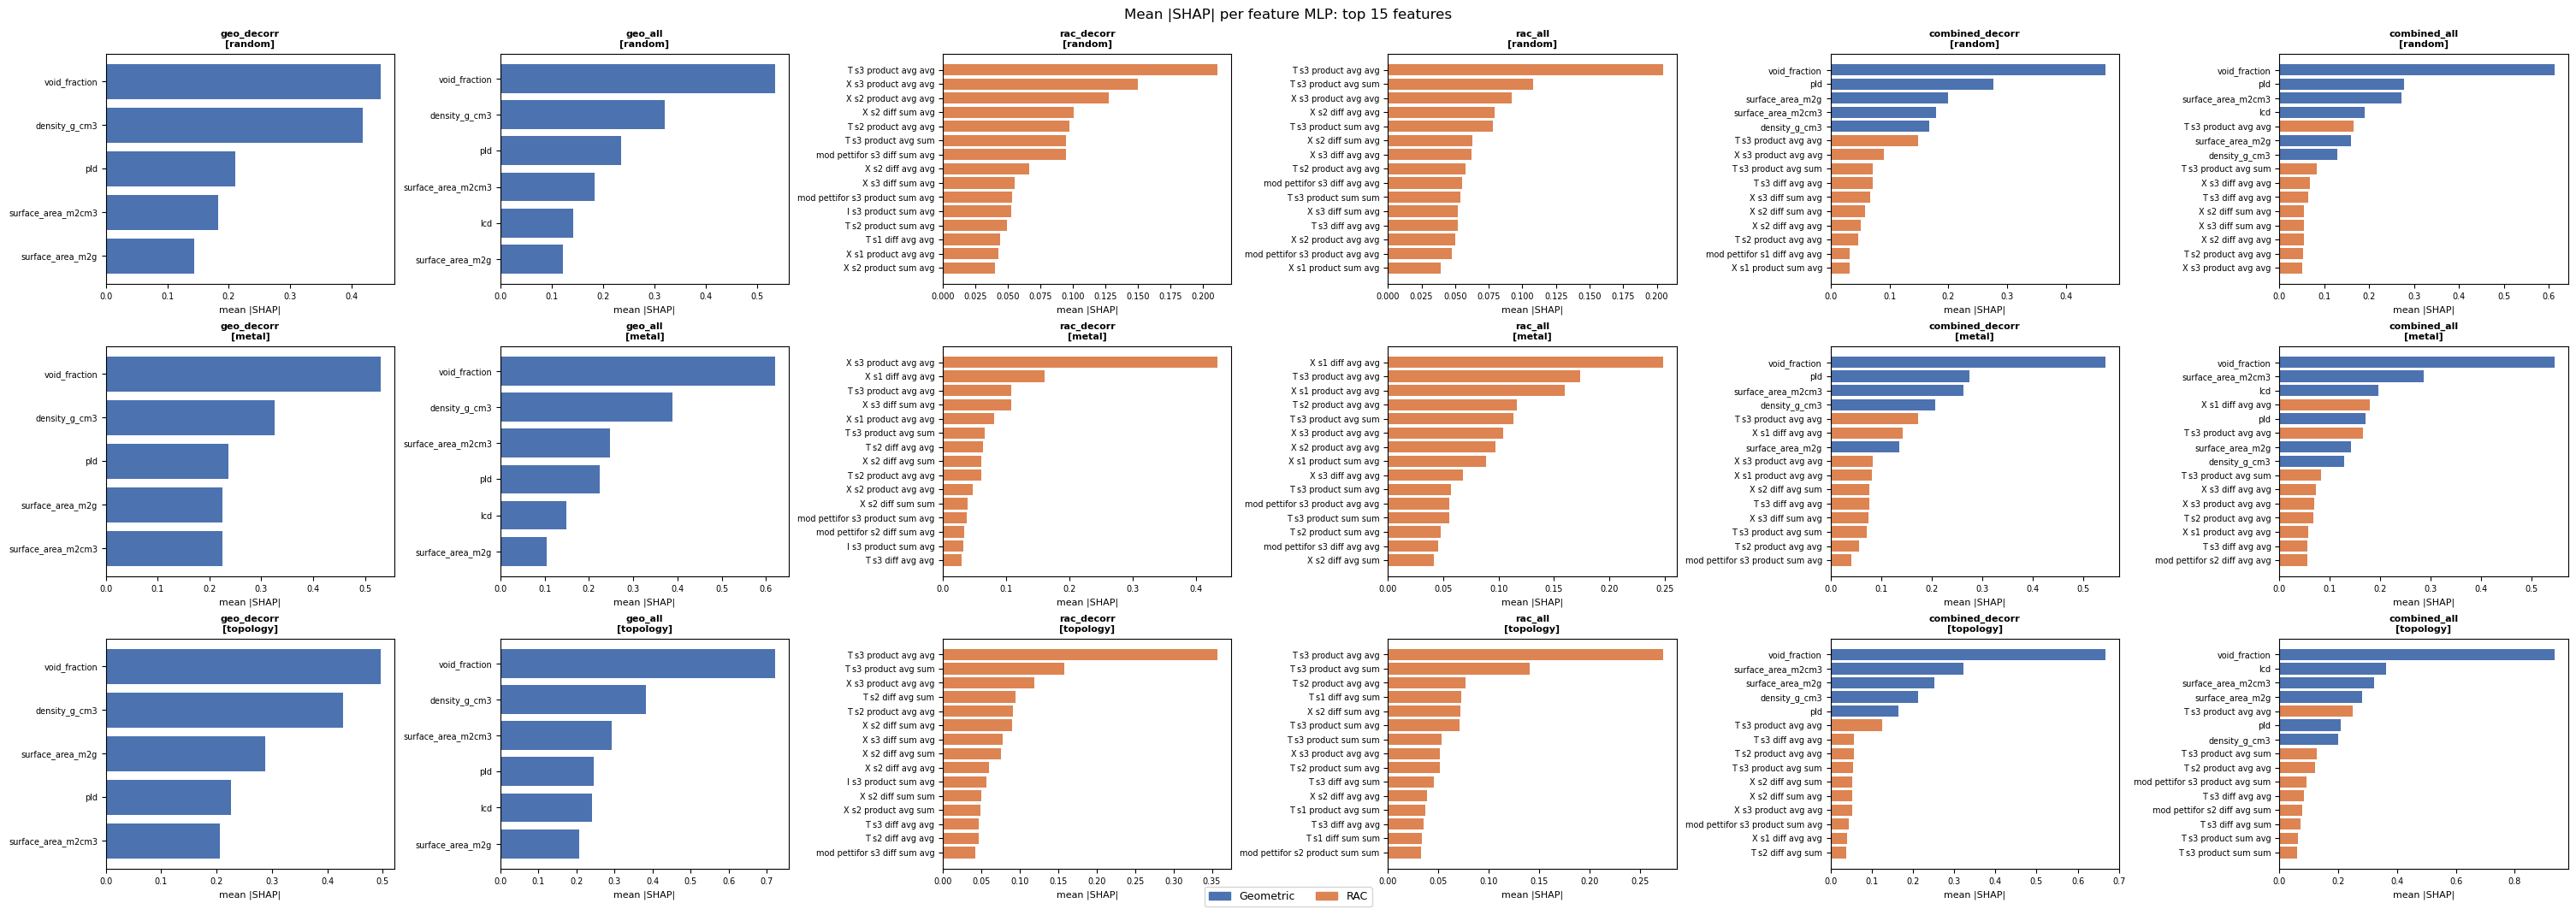

Saved shap_bar_all_experiments.pdf/png


In [10]:
TOP_N = 15

fig, axes = plt.subplots(
    len(SPLITS), len(FEATURE_SETS),
    figsize=(5 * len(FEATURE_SETS), 3.5 * len(SPLITS)),
    constrained_layout=True,
)

for row, sp in enumerate(SPLITS):
    for col, fs in enumerate(FEATURE_SETS):
        ax  = axes[row][col]
        tag = f"{fs}__{sp}"

        if tag not in shap_results:
            ax.set_visible(False)
            continue

        top = mean_abs_shap(shap_results[tag], top_n=TOP_N)
        labels = [shorten(f) for f in top.index]
        colors = [GEO_COLOUR if is_geo(f) else RAC_COLOUR for f in top.index]

        ax.barh(range(len(top)), top.values[::-1], color=colors[::-1], edgecolor="none")
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(labels[::-1], fontsize=7)
        ax.set_xlabel("mean |SHAP|", fontsize=8)
        ax.set_title(f"{fs}\n[{sp}]", fontsize=8, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7)

from matplotlib.patches import Patch
legend_handles = [Patch(color=GEO_COLOUR, label="Geometric"),
                  Patch(color=RAC_COLOUR,  label="RAC")]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Mean |SHAP| per feature MLP: top 15 features", fontsize=12)

plt.savefig(RESULTS_DIR / "shap_bar_all_experiments.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_bar_all_experiments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_bar_all_experiments.pdf/png")

## Cross-split comparison

`combined_all`: top-15 features on random split tracked across all three split strategies.

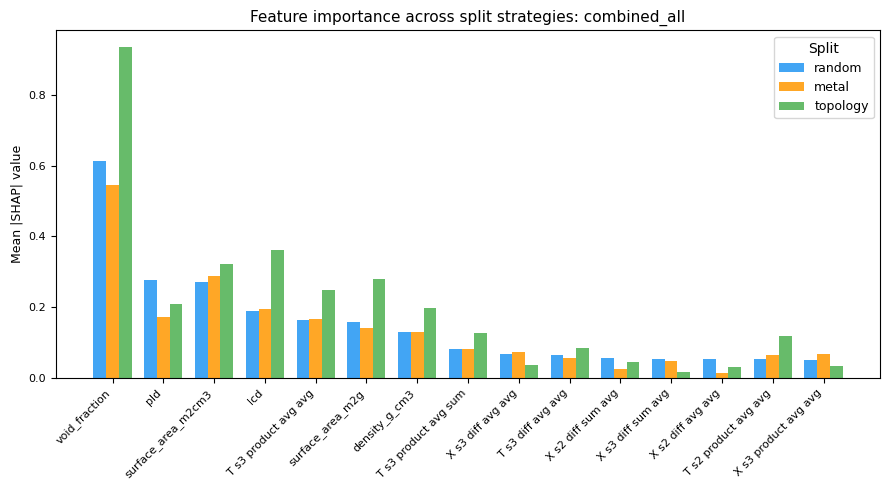

Saved shap_cross_split_combined_all.pdf/png


In [11]:
fs = "combined_all"
anchor_tag = f"{fs}__random"

if anchor_tag in shap_results:
    top_feats = mean_abs_shap(shap_results[anchor_tag], top_n=15).index.tolist()

    data = {}
    for sp in SPLITS:
        tag = f"{fs}__{sp}"
        if tag in shap_results:
            imp = mean_abs_shap(shap_results[tag])
            data[sp] = [imp.get(f, 0.0) for f in top_feats]

    df_cross = pd.DataFrame(data, index=[shorten(f) for f in top_feats])

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(top_feats))
    width = 0.25
    colors_split = {"random": "#2196F3", "metal": "#FF9800", "topology": "#4CAF50"}

    for k, (sp, vals) in enumerate(df_cross.items()):
        ax.bar(x + k * width, vals, width, label=sp,
               color=colors_split.get(sp, "gray"), alpha=0.85, edgecolor="none")

    ax.set_xticks(x + width)
    ax.set_xticklabels(df_cross.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean |SHAP| value", fontsize=9)
    ax.set_title(f"Feature importance across split strategies: {fs}", fontsize=11)
    ax.legend(title="Split", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "shap_cross_split_combined_all.pdf", bbox_inches="tight")
    plt.savefig(RESULTS_DIR / "shap_cross_split_combined_all.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved shap_cross_split_combined_all.pdf/png")

## Geometric vs RAC contribution

    feature_set    split  geo_share  rac_share
combined_decorr   random       51.3       48.7
combined_decorr    metal       50.4       49.6
combined_decorr topology       57.1       42.9
   combined_all   random       49.1       50.9
   combined_all    metal       44.6       55.4
   combined_all topology       46.6       53.4


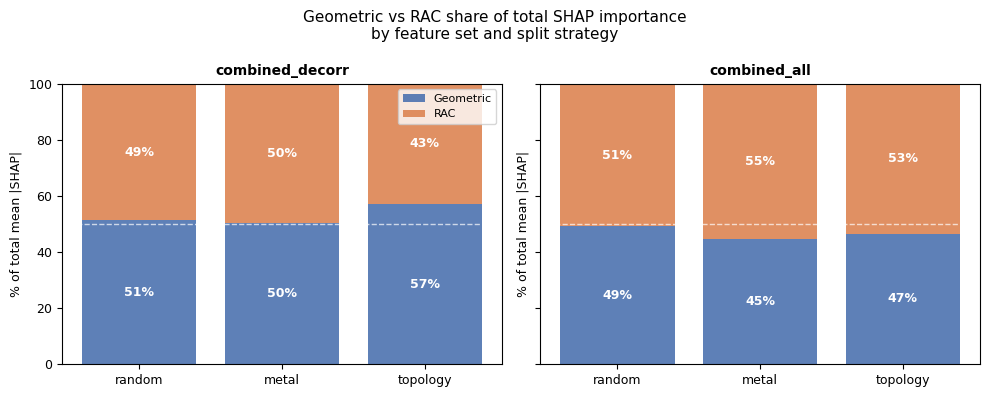

Saved shap_geo_vs_rac_contribution.pdf/png


In [7]:
combined_sets = ["combined_decorr", "combined_all"]
records = []

for fs in combined_sets:
    for sp in SPLITS:
        tag = f"{fs}__{sp}"
        if tag not in shap_results:
            continue
        imp = mean_abs_shap(shap_results[tag])
        geo_total = imp[[f for f in imp.index if     is_geo(f)]].sum()
        rac_total = imp[[f for f in imp.index if not is_geo(f)]].sum()
        total     = geo_total + rac_total
        records.append({
            "feature_set": fs, "split": sp,
            "geo_share": geo_total / total * 100,
            "rac_share": rac_total / total * 100,
        })

df_contrib = pd.DataFrame(records)
print(df_contrib[["feature_set", "split", "geo_share", "rac_share"]].round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, fs in zip(axes, combined_sets):
    sub = df_contrib[df_contrib["feature_set"] == fs].set_index("split").reindex(SPLITS)

    ax.bar(SPLITS, sub["geo_share"], color=GEO_COLOUR, label="Geometric", alpha=0.9)
    ax.bar(SPLITS, sub["rac_share"], bottom=sub["geo_share"],
           color=RAC_COLOUR, label="RAC", alpha=0.9)
    ax.set_ylim(0, 100)
    ax.set_ylabel("% of total mean |SHAP|", fontsize=9)
    ax.set_title(fs, fontsize=10, fontweight="bold")
    ax.axhline(50, color="white", linewidth=1, linestyle="--", alpha=0.7)
    ax.tick_params(labelsize=9)

    for i, sp in enumerate(SPLITS):
        if sp in sub.index and not pd.isna(sub.loc[sp, "geo_share"]):
            geo_s = sub.loc[sp, "geo_share"]
            rac_s = sub.loc[sp, "rac_share"]
            ax.text(i, geo_s / 2,       f"{geo_s:.0f}%", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
            ax.text(i, geo_s + rac_s/2, f"{rac_s:.0f}%", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")

axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Geometric vs RAC share of total SHAP importance\nby feature set and split strategy",
             fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "shap_geo_vs_rac_contribution.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_geo_vs_rac_contribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_geo_vs_rac_contribution.pdf/png")


## Beeswarm plots

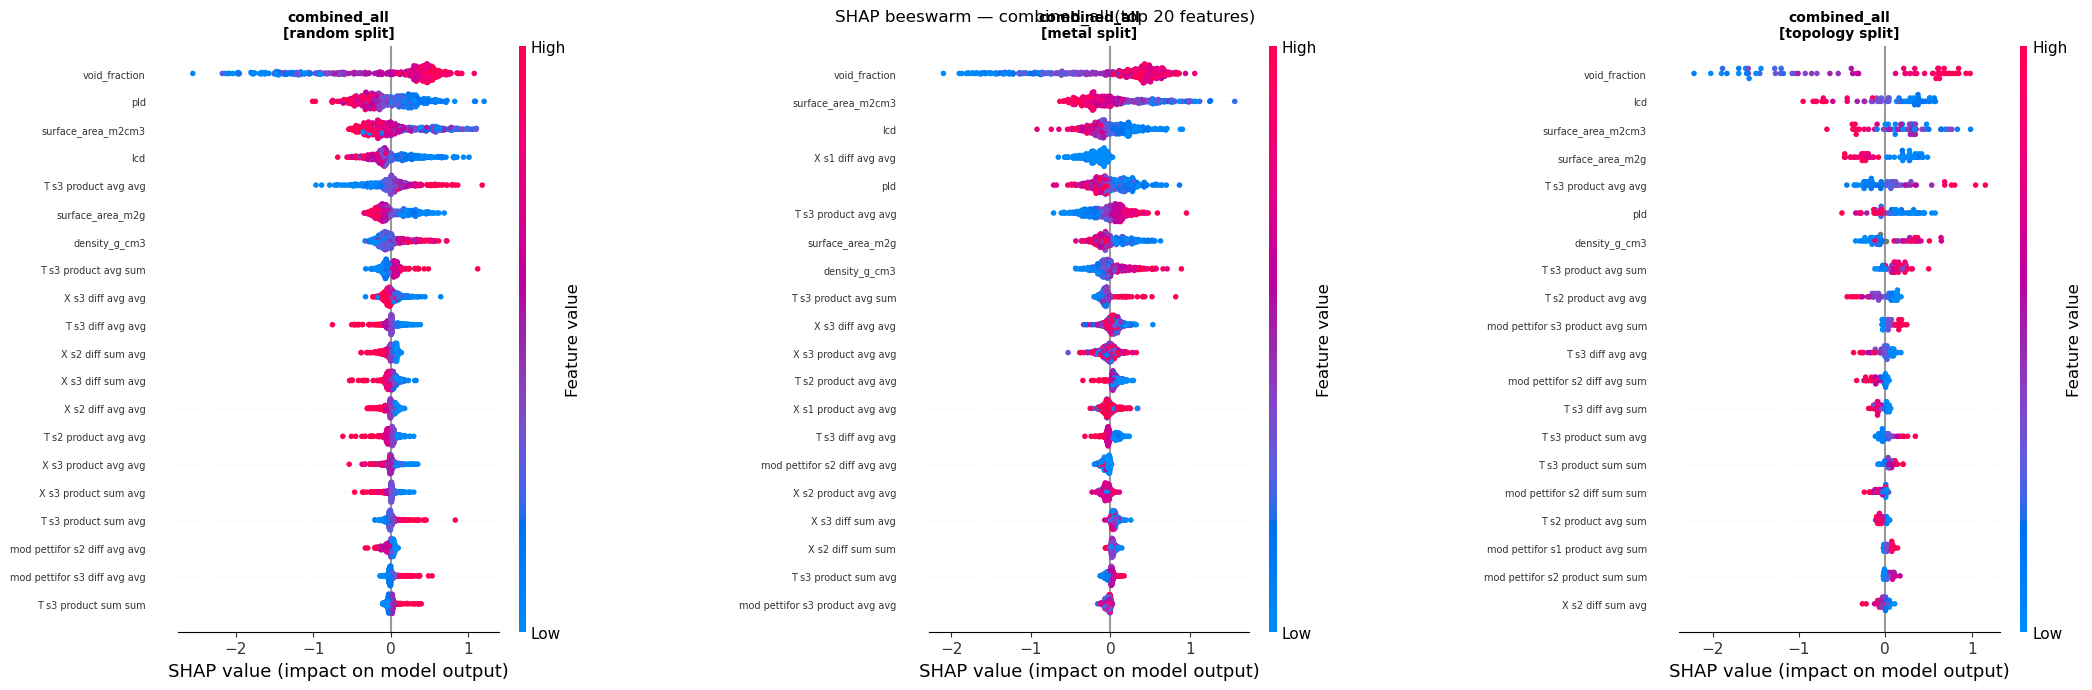

Saved shap_beeswarm_combined_all.pdf/png


In [8]:
fs       = "combined_all"
TOP_N_BEE = 20

fig, axes = plt.subplots(1, len(SPLITS), figsize=(7 * len(SPLITS), 7))

for ax, sp in zip(axes, SPLITS):
    tag = f"{fs}__{sp}"
    if tag not in shap_results:
        ax.set_visible(False)
        continue

    r          = shap_results[tag]
    sv         = r["shap_values"]
    feat_names = r["feature_names"]

    mean_imp  = np.abs(sv).mean(axis=0)
    top_idx   = np.argsort(mean_imp)[::-1][:TOP_N_BEE]
    sv_top    = sv[:, top_idx]
    X_top     = r["X_explain"][:, top_idx]
    names_top = [shorten(feat_names[i]) for i in top_idx]

    plt.sca(ax)
    shap.summary_plot(sv_top, X_top, feature_names=names_top,
                      max_display=TOP_N_BEE, show=False, plot_size=None, color_bar=True)
    ax.set_title(f"{fs}\n[{sp} split]", fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("SHAP beeswarm — combined_all (top 20 features)", fontsize=12)
plt.savefig(RESULTS_DIR / "shap_beeswarm_combined_all.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_beeswarm_combined_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_beeswarm_combined_all.pdf/png")

## Save full SHAP importance CSV

In [9]:
rows = []
for tag, r in shap_results.items():
    imp = mean_abs_shap(r)
    for feat, val in imp.items():
        rows.append({
            "experiment": tag,
            "feature_set": r["feature_set"],
            "split": r["split"],
            "feature": feat,
            "feature_type": "geo" if is_geo(feat) else "rac",
            "mean_abs_shap": val,
        })

df_shap = pd.DataFrame(rows)
out_csv = RESULTS_DIR / "shap_importances.csv"
df_shap.to_csv(out_csv, index=False)
print(f"Saved {out_csv}  ({len(df_shap):,} rows)")

print("\nTop-5 features per experiment:")
for tag, grp in df_shap.groupby("experiment"):
    top5 = grp.nlargest(5, "mean_abs_shap")[["feature", "feature_type", "mean_abs_shap"]]
    print(f"\n  {tag}")
    for _, row in top5.iterrows():
        print(f"    {row['mean_abs_shap']:.4f}  [{row['feature_type']}]  {shorten(row['feature'])}")

Saved /Users/hannah/Desktop/ethz/Semester6/dc-mof-project/results/mlp/shap/shap_importances.csv  (822 rows)

Top-5 features per experiment:

  combined_all__metal
    0.5451  [geo]  void_fraction
    0.2868  [geo]  surface_area_m2cm3
    0.1958  [geo]  lcd
    0.1790  [rac]  X s1 diff avg avg
    0.1715  [geo]  pld

  combined_all__random
    0.6126  [geo]  void_fraction
    0.2772  [geo]  pld
    0.2724  [geo]  surface_area_m2cm3
    0.1897  [geo]  lcd
    0.1645  [rac]  T s3 product avg avg

  combined_all__topology
    0.9348  [geo]  void_fraction
    0.3629  [geo]  lcd
    0.3225  [geo]  surface_area_m2cm3
    0.2798  [geo]  surface_area_m2g
    0.2493  [rac]  T s3 product avg avg

  combined_decorr__metal
    0.5446  [geo]  void_fraction
    0.2752  [geo]  pld
    0.2626  [geo]  surface_area_m2cm3
    0.2078  [geo]  density_g_cm3
    0.1737  [rac]  T s3 product avg avg

  combined_decorr__random
    0.4662  [geo]  void_fraction
    0.2756  [geo]  pld
    0.1999  [geo]  surface_are